In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

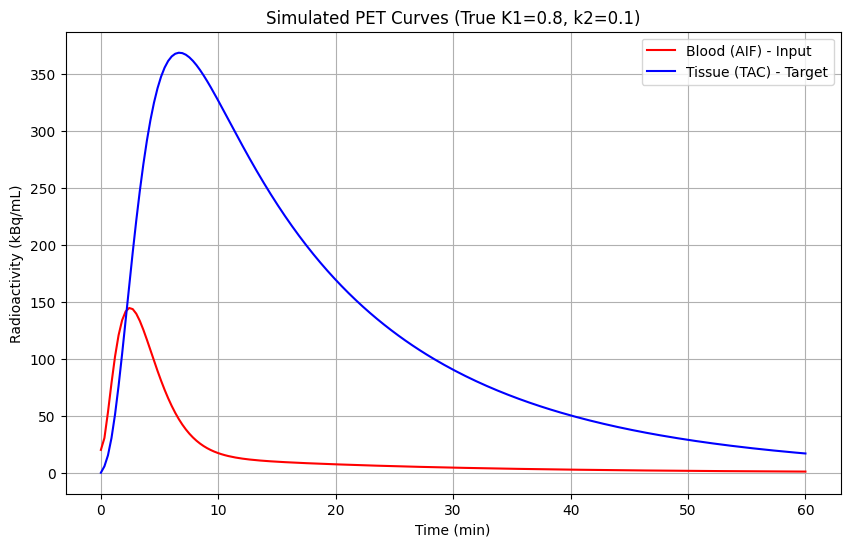

In [18]:
#Stimulate PET curve
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. 定义时间点 (例如：60分钟的扫描，前面采样快，后面采样慢)
t = np.linspace(0, 60, 200) 

# 2. 模拟 AIF (输入函数)：通常是一个快速上升后呈指数下降的形状
def simulated_aif(t):
    # 这是一个常用的数学近似：Feng模型简化版
    return 150 * (t**2) * np.exp(-0.8 * t) + 20 * np.exp(-0.05 * t)

cp_values = simulated_aif(t)

# 3. 定义 1TCM 模型微分方程
# dCt/dt = K1*Cp - k2*Ct
def tissue_model(Ct, t, K1, k2):
    return K1 * simulated_aif(t) - k2 * Ct

# 4. 设定生理参数并求解
K1_true = 0.8  # 假设灌注/转运率
k2_true = 0.1  # 假设洗脱率
ct_values = odeint(tissue_model, 0, t, args=(K1_true, k2_true))

# 5. 绘图
plt.figure(figsize=(10, 6))
plt.plot(t, cp_values, 'r-', label='Blood (AIF) - Input')
plt.plot(t, ct_values, 'b-', label='Tissue (TAC) - Target')
plt.title(f'Simulated PET Curves (True K1={K1_true}, k2={k2_true})')
plt.xlabel('Time (min)')
plt.ylabel('Radioactivity (kBq/mL)')
plt.legend()
plt.grid(True)
plt.show()

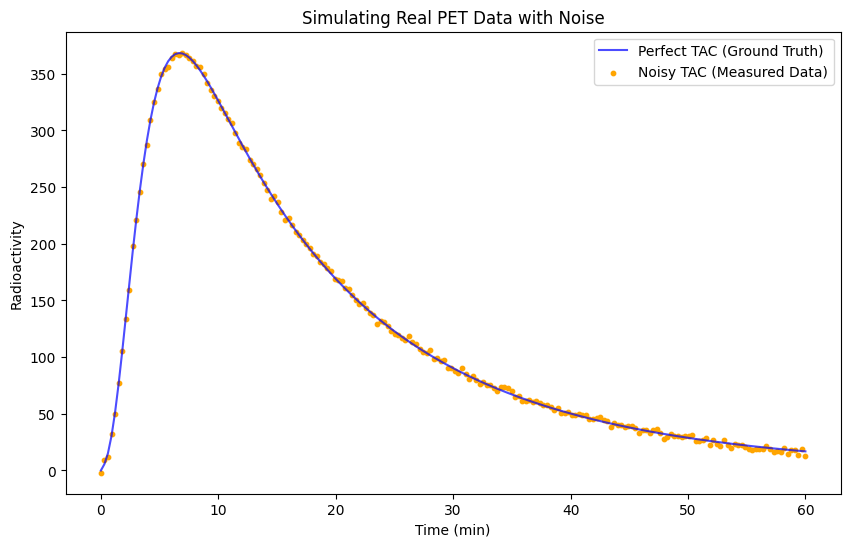

In [4]:
# 设定噪声强度 (标准差)
noise_level = 2.0 

# 在原本完美的 ct_values 上加上随机噪声
# np.random.normal 会生成符合正态分布的随机数
noise = np.random.normal(0, noise_level, size=ct_values.shape)
ct_noisy = ct_values + noise

# 绘图对比
plt.figure(figsize=(10, 6))
plt.plot(t, ct_values, 'b-', label='Perfect TAC (Ground Truth)', alpha=0.7)
plt.scatter(t, ct_noisy, color='orange', s=10, label='Noisy TAC (Measured Data)')
plt.title("Simulating Real PET Data with Noise")
plt.xlabel('Time (min)')
plt.ylabel('Radioactivity')
plt.legend()
plt.show()

In [5]:
from scipy.optimize import curve_fit

# A. 定义一个拟合用的包装函数
# 这个函数必须接受 t 作为第一个参数，然后是我们要找的 K1, k2
def fit_func(t_array, K1_fit, k2_fit):
    # 这里我们重复之前的 odeint 逻辑
    # 注意：为了拟合，我们需要在函数内部重新计算模型
    res = odeint(tissue_model, 0, t_array, args=(K1_fit, k2_fit))
    return res.flatten()

# B. 开始拟合！
# p0 是初始猜测值 [K1, k2]
initial_guess = [1.0, 1.0]
popt, pcov = curve_fit(fit_func, t, ct_noisy.flatten(), p0=initial_guess)

# C. 提取结果
K1_estimated, k2_estimated = popt

print(f"--- 结果对比 ---")
print(f"真实 K1: {K1_true:.4f}  |  电脑估算 K1: {K1_estimated:.4f}")
print(f"真实 k2: {k2_true:.4f}  |  电脑估算 k2: {k2_estimated:.4f}")

--- 结果对比 ---
真实 K1: 0.8000  |  电脑估算 K1: 0.7981
真实 k2: 0.1000  |  电脑估算 k2: 0.0998


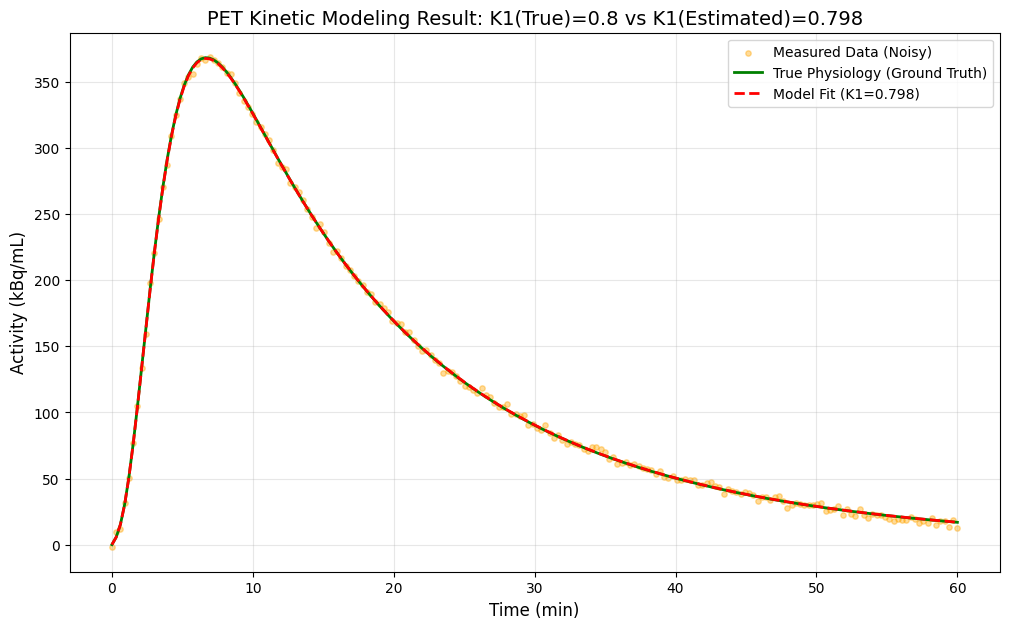

In [6]:
# 1. 用电脑猜出来的参数生成一条“拟合曲线”
ct_fitted = fit_func(t, K1_estimated, k2_estimated)

# 2. 开启大图模式
plt.figure(figsize=(12, 7))

# 画出观测到的带噪声的点（这是你的原始数据）
plt.scatter(t, ct_noisy, color='orange', alpha=0.4, s=15, label='Measured Data (Noisy)')

# 画出真实的线（上帝视角）
plt.plot(t, ct_values, 'g-', linewidth=2, label='True Physiology (Ground Truth)')

# 画出电脑拟合的线（算法成果）
plt.plot(t, ct_fitted, 'r--', linewidth=2, label=f'Model Fit (K1={K1_estimated:.3f})')

# 修饰图形
plt.title(f'PET Kinetic Modeling Result: K1(True)=0.8 vs K1(Estimated)={K1_estimated:.3f}', fontsize=14)
plt.xlabel('Time (min)', fontsize=12)
plt.ylabel('Activity (kBq/mL)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [7]:
VT = K1_estimated / k2_estimated
print(f"该组织的分布体积 VT 为: {VT:.4f}")

该组织的分布体积 VT 为: 8.0004


In [8]:
# 这里的感叹号告诉 Jupyter：请把这行命令发给系统的 Terminal 执行
!pip install h5py

In [19]:
# Data Loading
import h5py

file_path = 'brain_TAC.h5' # 既然你上传了，直接用文件名

with h5py.File(file_path, 'r') as f:
    print("文件中的关键词 (Keys):", list(f.keys()))
    
    for key in f.keys():
        # 修改这里：直接用 [:] 或者 .getvalue()
        # 如果是数据集(Dataset)，用 [()] 或 [:]
        # 为了保险，我们先看看它是什么类型
        item = f[key]
        if isinstance(item, h5py.Dataset):
            data = item[:] # 读取所有数据
            print(f"✅ 数据列 【{key}】 的形状: {data.shape}")
            print(f"   前5个数值: {data[:5]}")
        else:
            print(f"? 【{key}】 是一个组(Group)，里面可能还有子项")

文件中的关键词 (Keys): ['df_sub']
? 【df_sub】 是一个组(Group)，里面可能还有子项


In [10]:
import h5py
import pandas as pd

file_path = 'brain_TAC.h5'

with h5py.File(file_path, 'r') as f:
    # 进入 df_sub 这一层
    group = f['df_sub']
    print(f"进入 'df_sub' 组，发现子项: {list(group.keys())}")
    
    # 尝试自动将其转换回 Pandas 表格（最方便的方法）
    try:
        # 很多时候可以用 pandas 直接读取 h5
        df = pd.read_hdf(file_path, key='df_sub')
        print("\n✅ 成功解析为表格！前 5 行数据如下：")
        print(df.head())
        
        # 保存到变量供后续建模使用
        my_data = df
    except Exception as e:
        print(f"\n❌ 自动读取失败，原因: {e}")
        print("尝试手动列出组内数据集内容：")
        for sub_key in group.keys():
            if isinstance(group[sub_key], h5py.Dataset):
                print(f"数据集 {sub_key}: {group[sub_key][:][:5]} ...")

进入 'df_sub' 组，发现子项: ['axis0', 'axis1', 'block0_items', 'block0_values']

✅ 成功解析为表格！前 5 行数据如下：
   Frame duration (min)  Time (min)   AIF (Bq/mL)         64953
0              0.083333    0.041667 -3.663514e-15  0.000000e+00
1              0.083333    0.125000  1.105226e-14  0.000000e+00
2              0.083333    0.208333  2.599502e+00  0.000000e+00
3              0.083333    0.291667  1.321270e+03  3.253452e-13
4              0.083333    0.375000  8.220589e+03  8.427852e-13


In [11]:
!pip install tables

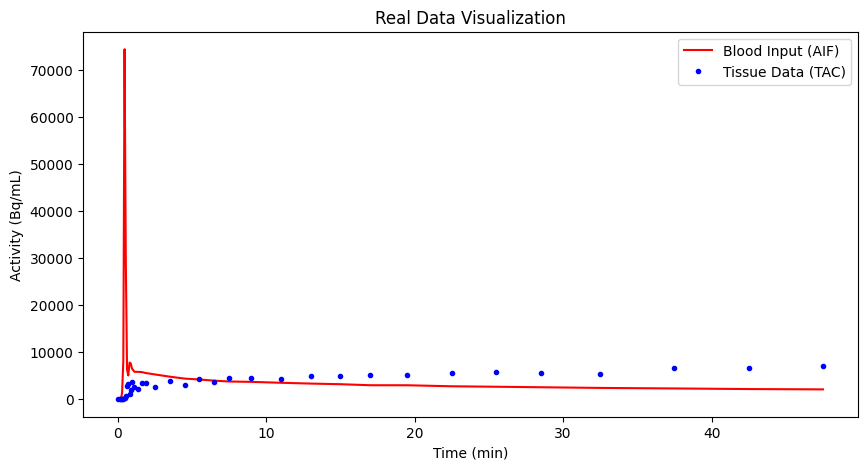

In [12]:
# Exploratory Data Analysis (EDA)
# 假设 df 是你刚才读出来的表格
# 1. 提取时间轴 (x轴)
t_real = df['Time (min)'].values

# 2. 提取输入函数 (Cp)
# 注意：有些 PET 数据初期会有极小的负数(噪声)，拟合前通常把它们归零
cp_real = df['AIF (Bq/mL)'].values
cp_real[cp_real < 0] = 0 

# 3. 提取组织数据 (Ct) - 请确认你的列名是否真的是 '64953'
# 如果列名不对，你可以通过 df.columns 查看
roi_column_name = '64953' 
ct_real = df[roi_column_name].values

# 4. 看看真实数据的样子
plt.figure(figsize=(10, 5))
plt.plot(t_real, cp_real, 'r-', label='Blood Input (AIF)')
plt.plot(t_real, ct_real, 'b.', label='Tissue Data (TAC)')
plt.xlabel('Time (min)')
plt.ylabel('Activity (Bq/mL)')
plt.legend()
plt.title('Real Data Visualization')
plt.show()

In [13]:
from scipy.interpolate import interp1d

# 创建一个插值函数，kind='linear' 表示用直线连接每个采样点
# fill_value="extrapolate" 确保超出时间范围时不会报错
cp_func = interp1d(t_real, cp_real, kind='linear', fill_value="extrapolate")

# 测试一下：输入一个时间，看看它能不能吐出浓度
print(f"在 0.5 分钟时的血液浓度估计值为: {cp_func(0.5):.2f}")

在 0.5 分钟时的血液浓度估计值为: 51897.95


拟合成功！
推算出的 K1 = 0.3469
推算出的 k2 = 0.2473
计算出的 VT (分布体积) = 1.4030


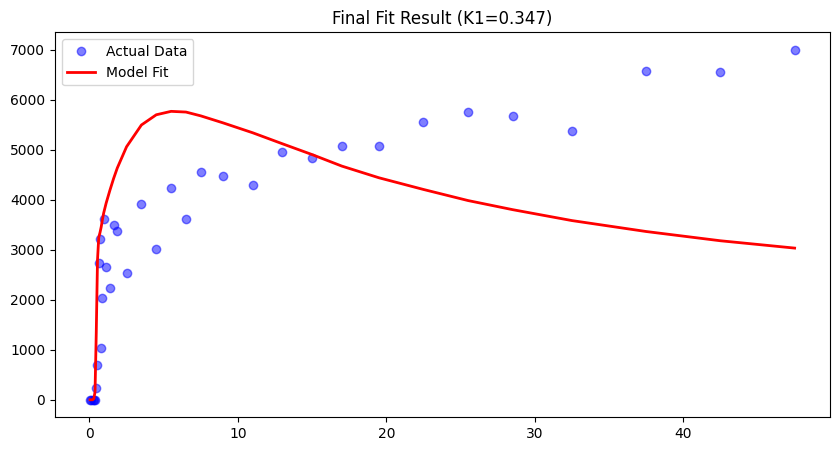

In [20]:
# 1TCM Fitting
from scipy.integrate import odeint
from scipy.optimize import curve_fit

# 1. 定义适配真实数据的 1TCM 模型
def fit_model_real(t_array, K1, k2):
    # 定义 ODE 内部逻辑，利用我们刚才创建的 cp_func
    def odes(Ct, t):
        return K1 * cp_func(t) - k2 * Ct
    
    # 求解 ODE。注意：t_array 是真实的时间点
    # 我们假设初始浓度 Ct(0) = 0
    predictions = odeint(odes, 0, t_array)
    return predictions.flatten()

# 2. 执行拟合
# 初始猜测：K1=0.5, k2=0.1 (根据经验给个大概值)
p0 = [0.5, 0.1]
# 设置参数范围，确保 K1 和 k2 都是正数 (bounds)
popt, pcov = curve_fit(fit_model_real, t_real, ct_real, p0=p0, bounds=(0, np.inf))

# 3. 提取拟合结果
K1_res, k2_res = popt
print(f"拟合成功！\n推算出的 K1 = {K1_res:.4f}\n推算出的 k2 = {k2_res:.4f}")
print(f"计算出的 VT (分布体积) = {K1_res/k2_res:.4f}")

# 4. 看看拟合得好不好
plt.figure(figsize=(10, 5))
plt.plot(t_real, ct_real, 'bo', alpha=0.5, label='Actual Data')
plt.plot(t_real, fit_model_real(t_real, *popt), 'r-', linewidth=2, label='Model Fit')
plt.legend()
plt.title(f'Final Fit Result (K1={K1_res:.3f})')
plt.show()

--- 2TCM 拟合结果 ---
K1: 0.2321, k2: 0.2935
k3: 0.0746, k4: 0.0116
总分布体积 VT: 5.8648


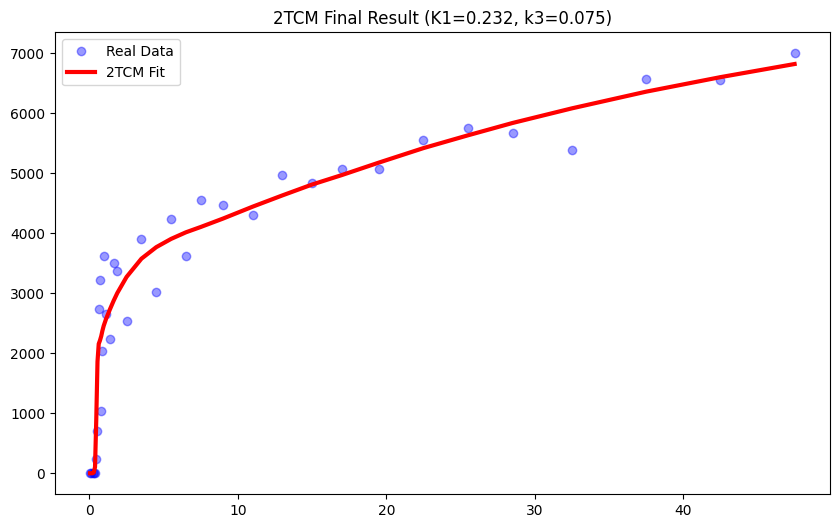

In [21]:
# 2TCM Fitting
# 1. 定义 2TCM 微分方程组
def model_2tcm_ode(C, t, K1, k2, k3, k4):
    C1, C2 = C
    Cp = cp_func(t) # 使用我们之前的插值函数
    
    dC1_dt = K1 * Cp - (k2 + k3) * C1 + k4 * C2
    dC2_dt = k3 * C1 - k4 * C2
    return [dC1_dt, dC2_dt]

# 2. 定义用于拟合的包装函数
def fit_model_2tcm(t_array, K1, k2, k3, k4):
    # 初始状态：C1=0, C2=0
    C0 = [0, 0]
    sol = odeint(model_2tcm_ode, C0, t_array, args=(K1, k2, k3, k4))
    # 总放射性浓度是两个池子的和
    return sol[:, 0] + sol[:, 1]

# 3. 执行拟合
# 初始猜测：K1, k2, k3, k4
p0_2tcm = [0.4, 0.1, 0.05, 0.01]
# 设定范围：所有速率常数必须为正
bounds_2tcm = (0, [2.0, 1.0, 1.0, 1.0]) 

try:
    popt_2, pcov_2 = curve_fit(fit_model_2tcm, t_real, ct_real, p0=p0_2tcm, bounds=bounds_2tcm)
    K1_2, k2_2, k3_2, k4_2 = popt_2
    
    print("--- 2TCM 拟合结果 ---")
    print(f"K1: {K1_2:.4f}, k2: {k2_2:.4f}")
    print(f"k3: {k3_2:.4f}, k4: {k4_2:.4f}")
    
    # 计算总分布体积 VT_total = (K1/k2) * (1 + k3/k4)
    VT_2 = (K1_2 / k2_2) * (1 + k3_2 / k4_2)
    print(f"总分布体积 VT: {VT_2:.4f}")

    # 4. 绘图对比
    plt.figure(figsize=(10, 6))
    plt.plot(t_real, ct_real, 'bo', alpha=0.4, label='Real Data')
    plt.plot(t_real, fit_model_2tcm(t_real, *popt_2), 'r-', linewidth=3, label='2TCM Fit')
    plt.title(f'2TCM Final Result (K1={K1_2:.3f}, k3={k3_2:.3f})')
    plt.legend()
    plt.show()

except Exception as e:
    print(f"拟合出错了: {e}")

In [16]:
def calculate_aic(n_points, rss, n_params):

    return n_points * np.log(rss/n_points) + 2 * n_params


residuals = ct_real - fit_model_2tcm(t_real, *popt_2)
rss_2tcm = np.sum(residuals**2)
aic_2tcm = calculate_aic(len(t_real), rss_2tcm, 4)

print(f"2TCM 的 AIC 分数: {aic_2tcm:.2f}")

2TCM 的 AIC 分数: 445.68


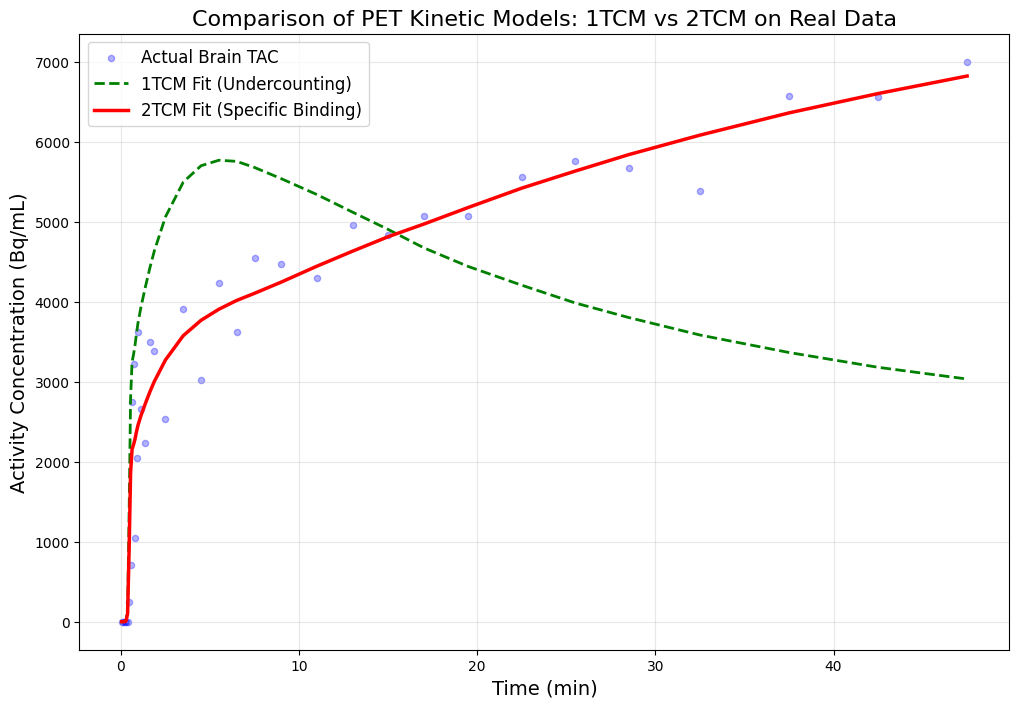

✅ 图片已成功保存至: /Users/xx/results/model_comparison.png


In [17]:
import matplotlib.pyplot as plt
import os

# 1. 计算拟合数据
ct_fit_1tcm = fit_model_real(t_real, *popt)
ct_fit_2tcm = fit_model_2tcm(t_real, *popt_2)

# 2. 修正后的绘图启动
# 删掉那个 ax，直接创建画布
plt.figure(figsize=(12, 8), dpi=100)

# 3. 绘图内容
plt.scatter(t_real, ct_real, color='blue', alpha=0.3, s=20, label='Actual Brain TAC')
plt.plot(t_real, ct_fit_1tcm, color='green', linestyle='--', linewidth=2, label='1TCM Fit (Undercounting)')
plt.plot(t_real, ct_fit_2tcm, color='red', linestyle='-', linewidth=2.5, label='2TCM Fit (Specific Binding)')

# 4. 修饰
plt.title('Comparison of PET Kinetic Models: 1TCM vs 2TCM on Real Data', fontsize=16)
plt.xlabel('Time (min)', fontsize=14)
plt.ylabel('Activity Concentration (Bq/mL)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# 5. 保存与展示 (顺序不能错！)
if not os.path.exists('results'):
    os.makedirs('results')

save_path = 'results/model_comparison.png'
plt.savefig(save_path, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ 图片已成功保存至: {os.path.abspath(save_path)}")